In [1]:
import copy
from pathlib import Path
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pytagi import Normalizer
import pytagi.metric as metric
from pytagi import Normalizer as normalizer
from canari import (
    DataProcess,
    Model,
    ModelOptimizer,
    SKF,
    SKFOptimizer,
    plot_data,
    plot_prediction,
    plot_skf_states,
    plot_states,
)
from canari.component import LocalTrend, LocalAcceleration, LstmNetwork, WhiteNoise


In [2]:
# data_file = "/Users/vuongdai/Desktop/backup_canari/TDSB_data/LGA/LGABAR/EXT/LGA010ESAPRG988.DAT"
data_file = "/Users/vuongdai/Desktop/backup_canari/TDSB_data/LTU/LTUBAR/PEN/ST/LTU014PIAEVA920.DAT"
df_raw = pd.read_csv(data_file,
                     sep=";",  # Semicolon as delimiter
                     quotechar='"',
                     engine="python",
                     na_values=[""],  # Treat empty strings as NaN
                     skipinitialspace=True,
                     encoding="ISO-8859-1",
                     )

In [3]:
df_raw.head()

,No pendule,Amenagement,Ouvrage,Date,Nombre Date,Niveau Reservoir (m),Deplacements cumulatif X (mm),Deplacements cumulatif Y (mm),Deplacements cumulatif Z (mm),Remarque,...,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39
0,LTU014PIAEVA920,LTU,LTUBAR,2002-12-06 00:00,37596.0,151.74,-3.02,-0.70,2.35,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,LTU014PIAEVA920,LTU,LTUBAR,2002-12-07 00:00,37597.0,151.78,-3.02,-0.58,2.33,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,LTU014PIAEVA920,LTU,LTUBAR,2002-12-08 00:00,37598.0,151.57,-2.98,-0.63,2.30,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LTU014PIAEVA920,LTU,LTUBAR,2002-12-09 00:00,37599.0,151.28,-3.04,-0.50,2.26,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,LTU014PIAEVA920,LTU,LTUBAR,2002-12-10 00:00,37600.0,151.36,-3.05,-0.41,2.21,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# df = df_raw[["Ext/Contraction (mm)"]]
df = df_raw[["Deplacements cumulatif X (mm)"]]

df.columns = ["ext"]
df.index = pd.to_datetime(df_raw["Date"])
# Resampling to weekly
df = df.resample("D").last()

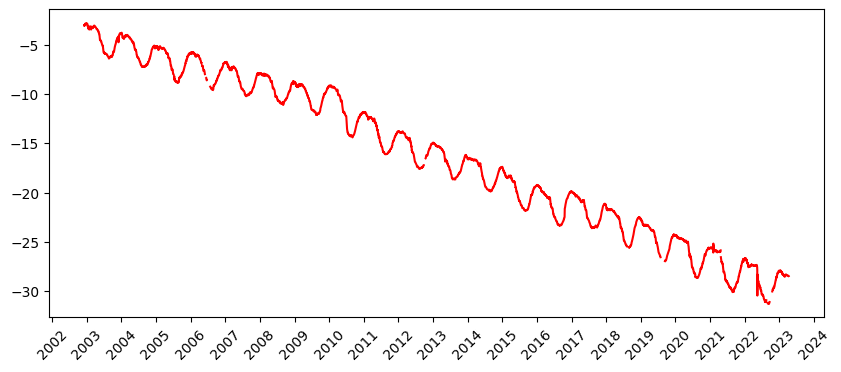

In [5]:
import matplotlib.dates as mdates
fig, ax = plt.subplots(figsize=(10, 4))
plt.plot(df.index, df["ext"], color="red")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.show()

In [6]:
# Data pre-processing
output_col = [0]
scale_const_mean = np.nanmean(df["ext"].iloc[0:365*2])
scale_const_std = np.nanstd(df["ext"].iloc[0:365*2])
data_processor = DataProcess(
    data=df,
    time_covariates=["day_of_year"],
    train_split=0.2,
    validation_split=0.08,
    test_split=0.67,
    output_col=output_col,
    scale_const_mean=[scale_const_mean, 185.96635262],
    scale_const_std=[scale_const_std, 106.78420119],
)
train_data, validation_data, test_data, all_data = data_processor.get_splits()
seed = np.random.randint(0, 100)

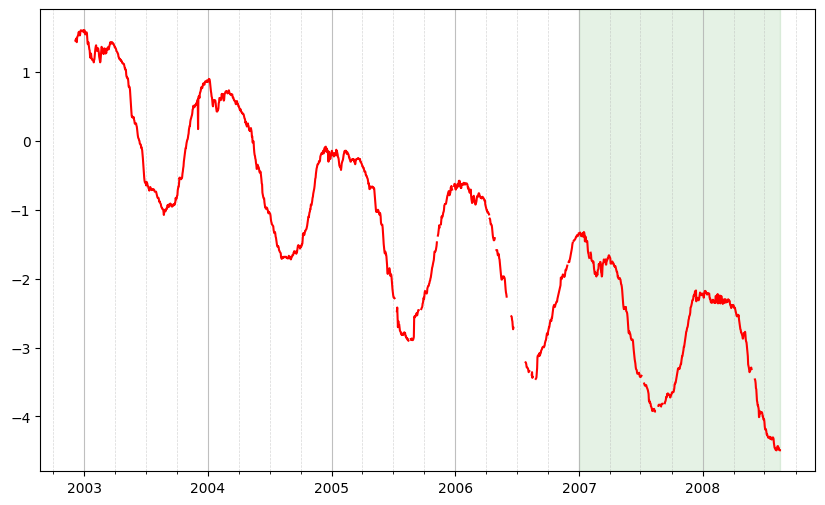

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_data(
    data_processor=data_processor,
    plot_column=output_col,
    standardization=True,
    plot_test_data=False,
    sub_plot=ax,
    validation_label="y",
)

In [8]:
param_optimization = True
smoother = False
num_trial_optim_model = 100

In [9]:
######### Define model with parameters #########
def model_with_parameters(param, train_data, validation_data):
    model = Model(
        LocalTrend(),
        LstmNetwork(
            look_back_len=param["look_back_len"],
            num_features=2,
            num_layer=1,
            # infer_len=365,
            num_hidden_unit=50,
            manual_seed=seed,
            smoother=smoother,
        ),
        WhiteNoise(std_error=param["sigma_v"]),
    )

    model.auto_initialize_baseline_states(train_data["y"][0 : 365 * 3])
    num_epoch = 50
    for epoch in range(num_epoch):
        mu_validation_preds, std_validation_preds, _ = model.lstm_train(
            train_data=train_data,
            validation_data=validation_data,
        )

        mu_validation_preds_unnorm = normalizer.unstandardize(
            mu_validation_preds,
            data_processor.scale_const_mean[data_processor.output_col],
            data_processor.scale_const_std[data_processor.output_col],
        )

        std_validation_preds_unnorm = normalizer.unstandardize_std(
            std_validation_preds,
            data_processor.scale_const_std[data_processor.output_col],
        )

        validation_obs = data_processor.get_data("validation").flatten()
        validation_log_lik = metric.log_likelihood(
            prediction=mu_validation_preds_unnorm,
            observation=validation_obs,
            std=std_validation_preds_unnorm,
        )

        model.early_stopping(
            evaluate_metric=-validation_log_lik,
            current_epoch=epoch,
            max_epoch=num_epoch,
        )
        model.metric_optim = model.early_stop_metric

        if model.stop_training:
            break

    #### Define SKF model with parameters #########

    abnorm_model = Model(
        LocalAcceleration(),
        LstmNetwork(),
        WhiteNoise(),
    )
    skf = SKF(
        norm_model=model,
        abnorm_model=abnorm_model,
        std_transition_error=param["std_transition_error"],
        norm_to_abnorm_prob=param["norm_to_abnorm_prob"],
    )

    skf.save_initial_states()

    filter_marginal_abnorm_prob, states, mu_preds, std_preds = skf.filter(
        data=all_data
    )

    mu_preds_unnorm = normalizer.unstandardize(
        mu_preds,
        data_processor.scale_const_mean[data_processor.output_col],
        data_processor.scale_const_std[data_processor.output_col],
    )

    std_preds_unnorm = normalizer.unstandardize_std(
        std_preds,
        data_processor.scale_const_std[data_processor.output_col],
    )

    obs_all = data_processor.get_data("all").flatten()
    log_lik_all = metric.log_likelihood(
        prediction=mu_preds_unnorm,
        observation=obs_all,
        std=std_preds_unnorm,
    )
    skf.metric_optim = -log_lik_all

    skf.load_initial_states()

    return skf, filter_marginal_abnorm_prob, states

#   1/100 - Metric: 1.117 - Parameter: {'look_back_len': 90, 'sigma_v': 0.1278915561923703, 'std_transition_error': 8.191622159703683e-06, 'norm_to_abnorm_prob': 9.54736979904148e-06}
#   2/100 - Metric: 5.613 - Parameter: {'look_back_len': 37, 'sigma_v': 0.13798674730313684, 'std_transition_error': 5.665424644679388e-06, 'norm_to_abnorm_prob': 5.977614770732927e-06}
#   3/100 - Metric: 1.480 - Parameter: {'look_back_len': 55, 'sigma_v': 0.18850293888705957, 'std_transition_error': 5.9659419308426735e-06, 'norm_to_abnorm_prob': 3.4074224604399255e-06}


2025-11-19 14:20:36,632	ERROR tune_controller.py:1331 -- Trial task failed for trial objective_6ed4083e
Traceback (most recent call last):
  File "/opt/miniconda3/envs/canari/lib/python3.10/site-packages/ray/air/execution/_internal/event_manager.py", line 110, in resolve_future
    result = ray.get(future)
  File "/opt/miniconda3/envs/canari/lib/python3.10/site-packages/ray/_private/auto_init_hook.py", line 22, in auto_init_wrapper
    return fn(*args, **kwargs)
  File "/opt/miniconda3/envs/canari/lib/python3.10/site-packages/ray/_private/client_mode_hook.py", line 104, in wrapper
    return func(*args, **kwargs)
  File "/opt/miniconda3/envs/canari/lib/python3.10/site-packages/ray/_private/worker.py", line 2882, in get
    values, debugger_breakpoint = worker.get_objects(object_refs, timeout=timeout)
  File "/opt/miniconda3/envs/canari/lib/python3.10/site-packages/ray/_private/worker.py", line 968, in get_objects
    raise value.as_instanceof_cause()
ray.exceptions.RayTaskError(LinAlgE

#   4/100 - Metric: 5.134 - Parameter: {'look_back_len': 46, 'sigma_v': 0.07695358298397977, 'std_transition_error': 2.3020891467317752e-06, 'norm_to_abnorm_prob': 8.937217864953006e-06}
#   5/100 - Metric: 1.728 - Parameter: {'look_back_len': 76, 'sigma_v': 0.07290217121566014, 'std_transition_error': 8.507652826599774e-06, 'norm_to_abnorm_prob': 2.0643724053692062e-06}
#   6/100 - Metric: 1.165 - Parameter: {'look_back_len': 56, 'sigma_v': 0.08501116469616644, 'std_transition_error': 7.821045104385632e-06, 'norm_to_abnorm_prob': 9.690034925748524e-06}
#   7/100 - Metric: 3.913 - Parameter: {'look_back_len': 56, 'sigma_v': 0.11190371933537588, 'std_transition_error': 1.5714034254103347e-06, 'norm_to_abnorm_prob': 8.942507673578086e-06}
#   8/100 - Metric: 4.216 - Parameter: {'look_back_len': 34, 'sigma_v': 0.018261868240541275, 'std_transition_error': 6.794098524125418e-06, 'norm_to_abnorm_prob': 8.308607310769381e-06}
#   9/100 - Metric: 1.721 - Parameter: {'look_back_len': 43, 'sigm

2025-11-19 14:21:06,154	ERROR tune_controller.py:1331 -- Trial task failed for trial objective_645154a8
Traceback (most recent call last):
  File "/opt/miniconda3/envs/canari/lib/python3.10/site-packages/ray/air/execution/_internal/event_manager.py", line 110, in resolve_future
    result = ray.get(future)
  File "/opt/miniconda3/envs/canari/lib/python3.10/site-packages/ray/_private/auto_init_hook.py", line 22, in auto_init_wrapper
    return fn(*args, **kwargs)
  File "/opt/miniconda3/envs/canari/lib/python3.10/site-packages/ray/_private/client_mode_hook.py", line 104, in wrapper
    return func(*args, **kwargs)
  File "/opt/miniconda3/envs/canari/lib/python3.10/site-packages/ray/_private/worker.py", line 2882, in get
    values, debugger_breakpoint = worker.get_objects(object_refs, timeout=timeout)
  File "/opt/miniconda3/envs/canari/lib/python3.10/site-packages/ray/_private/worker.py", line 968, in get_objects
    raise value.as_instanceof_cause()
ray.exceptions.RayTaskError(LinAlgE

#  11/100 - Metric: 4.277 - Parameter: {'look_back_len': 94, 'sigma_v': 0.13145671360934205, 'std_transition_error': 1.3983014697356826e-06, 'norm_to_abnorm_prob': 2.0052313049753702e-06}
#  12/100 - Metric: 3.984 - Parameter: {'look_back_len': 44, 'sigma_v': 0.08761181095534235, 'std_transition_error': 5.0246252052025095e-06, 'norm_to_abnorm_prob': 5.4124425689733165e-06}


...

#  62/100 - Metric: 0.950 - Parameter: {'look_back_len': 31, 'sigma_v': 0.06958750471870943, 'std_transition_error': 9.8164052364674e-06, 'norm_to_abnorm_prob': 2.7269770471605087e-06}


(objective pid=81026) /opt/miniconda3/envs/canari/lib/python3.10/site-packages/pytagi/metric.py:104: RuntimeWarning: Mean of empty slice
(objective pid=81026)   return np.nanmean(log_lik)
2025-11-19 14:28:03,786	ERROR tune_controller.py:1331 -- Trial task failed for trial objective_86af5f11
Traceback (most recent call last):
  File "/opt/miniconda3/envs/canari/lib/python3.10/site-packages/ray/air/execution/_internal/event_manager.py", line 110, in resolve_future
    result = ray.get(future)
  File "/opt/miniconda3/envs/canari/lib/python3.10/site-packages/ray/_private/auto_init_hook.py", line 22, in auto_init_wrapper
    return fn(*args, **kwargs)
  File "/opt/miniconda3/envs/canari/lib/python3.10/site-packages/ray/_private/client_mode_hook.py", line 104, in wrapper
    return func(*args, **kwargs)
  File "/opt/miniconda3/envs/canari/lib/python3.10/site-packages/ray/_private/worker.py", line 2882, in get
    values, debugger_breakpoint = worker.get_objects(object_refs, timeout=timeout)


#  63/100 - Metric: 1.319 - Parameter: {'look_back_len': 63, 'sigma_v': 0.04584105495789209, 'std_transition_error': 6.698974537995152e-06, 'norm_to_abnorm_prob': 1.4032362392635465e-06}


2025-11-19 14:28:30,571	ERROR tune_controller.py:1331 -- Trial task failed for trial objective_e78f8146
Traceback (most recent call last):
  File "/opt/miniconda3/envs/canari/lib/python3.10/site-packages/ray/air/execution/_internal/event_manager.py", line 110, in resolve_future
    result = ray.get(future)
  File "/opt/miniconda3/envs/canari/lib/python3.10/site-packages/ray/_private/auto_init_hook.py", line 22, in auto_init_wrapper
    return fn(*args, **kwargs)
  File "/opt/miniconda3/envs/canari/lib/python3.10/site-packages/ray/_private/client_mode_hook.py", line 104, in wrapper
    return func(*args, **kwargs)
  File "/opt/miniconda3/envs/canari/lib/python3.10/site-packages/ray/_private/worker.py", line 2882, in get
    values, debugger_breakpoint = worker.get_objects(object_refs, timeout=timeout)
  File "/opt/miniconda3/envs/canari/lib/python3.10/site-packages/ray/_private/worker.py", line 968, in get_objects
    raise value.as_instanceof_cause()
ray.exceptions.RayTaskError(LinAlgE

#  64/100 - Metric: 2.944 - Parameter: {'look_back_len': 58, 'sigma_v': 0.00609302182717892, 'std_transition_error': 6.681285475216243e-06, 'norm_to_abnorm_prob': 2.1027805021655465e-06}
-----
Optimal parameters at trial #49: {'look_back_len': 54, 'sigma_v': 0.04736936842641461, 'std_transition_error': 4.510869301349328e-06, 'norm_to_abnorm_prob': 4.156561281872397e-06}
-----


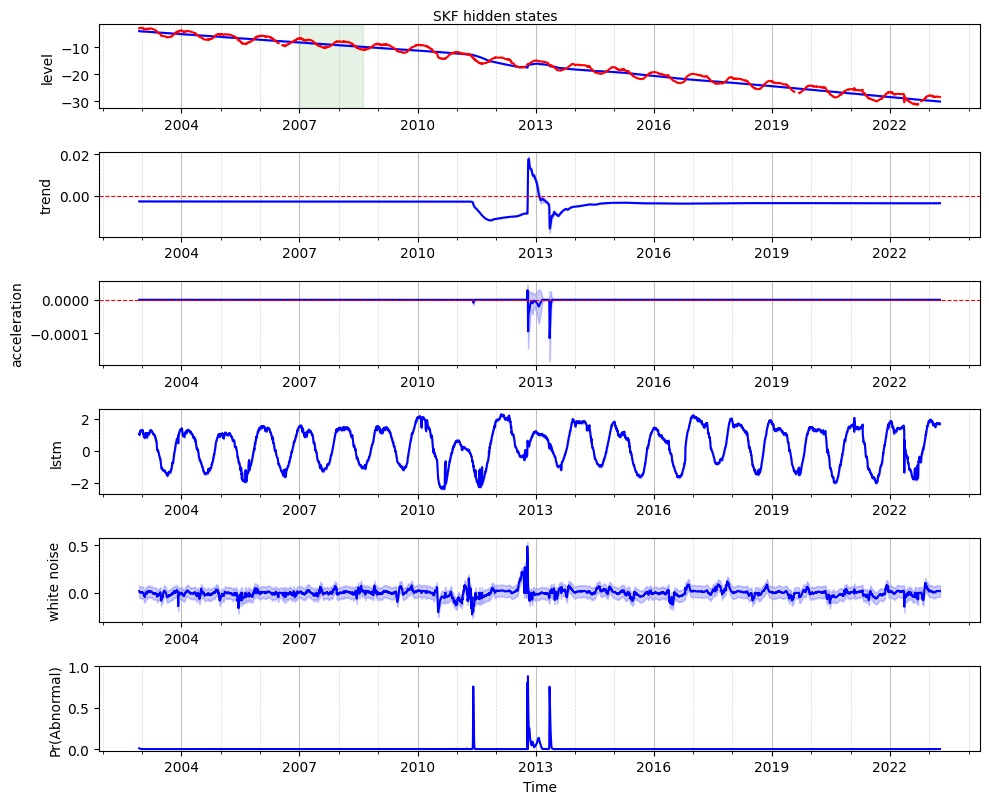

In [10]:
if param_optimization:
    param_space = {
        "look_back_len": [30, 100],
        "sigma_v": [1e-3, 2e-1],
        "std_transition_error": [1e-6, 1e-5],
        "norm_to_abnorm_prob": [1e-6, 1e-5],
    }
    # Define optimizer
    model_optimizer = ModelOptimizer(
        model=model_with_parameters,
        param_space=param_space,
        train_data=train_data,
        validation_data=validation_data,
        num_optimization_trial=num_trial_optim_model,
    )
    model_optimizer.optimize()
    # Get best model
    param = model_optimizer.get_best_param()
    skf_optim, filter_marginal_abnorm_prob, states = model_with_parameters(
        param, train_data, validation_data
    )

    skf_optim_dict = skf_optim.get_dict()
    skf_optim_dict["model_param"] = param
    skf_optim_dict["cov_names"] = train_data["cov_names"]
    with open("/Users/vuongdai/GitHub/canari/saved_params/benchmark_14_LL_daily_1.pkl", "wb") as f:
        pickle.dump(skf_optim_dict, f)
else:
    with open("/Users/vuongdai/GitHub/canari/saved_params/benchmark_14_LL_daily_1.pkl", "rb") as f:
        skf_optim_dict = pickle.load(f)
    skf_optim = SKF.load_dict(skf_optim_dict)

filter_marginal_abnorm_prob, states, *_ = skf_optim.filter(data=all_data)
smooth_marginal_abnorm_prob, states = skf_optim.smoother()

fig, ax = plot_skf_states(
    data_processor=data_processor,
    states=states,
    model_prob=filter_marginal_abnorm_prob,
)
fig.suptitle("SKF hidden states", fontsize=10, y=1)
plt.savefig("/Users/vuongdai/GitHub/canari/saved_results/BM14_daily_1.png")
plt.show()